# Multi-Station Validation: FSM2 vs seNorge vs Observations

This notebook validates snow depth models across multiple observation stations in Jotunheimen.

In [9]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Define Stations and Coordinates

Station information with WGS84 and UTM32N coordinates

In [20]:
import json

# Load station metadata from SNOWPACK data
with open("../data/SNOWPACK/vstations.json", "r") as f:
    all_stations = json.load(f)

# Load observation data first to get station list
obs_data_temp = pd.read_csv(
    "../data/snowdepth.csv",
    sep=";",
    header=None,
    skiprows=1
)
obs_data_temp.columns = ["station_name", "station_id", "time", "snow_depth"]

# Get unique stations from CSV (convert to string and remove NaN)
unique_stations = obs_data_temp[["station_name", "station_id"]].drop_duplicates()
unique_stations["station_id"] = unique_stations["station_id"].astype(str).str.strip()
unique_stations = unique_stations.dropna()

print(f"Found {len(unique_stations)} unique station codes in snowdepth.csv:")
for idx, row in unique_stations.iterrows():
    print(f"  {row['station_id']}: {row['station_name']}")

# Build stations_info by matching with vstations coordinates
stations_info = {}
missing_coords = []

for idx, row in unique_stations.iterrows():
    station_code = str(row['station_id']).strip()
    station_name = row['station_name']
    
    # Search for this station in vstations.json
    found = False
    for vstation_id, vstation_data in all_stations.items():
        if vstation_data.get('easting') and vstation_data.get('northing'):
            stations_info[station_name] = {
                'station_code': station_code,
                'lon_wgs84': vstation_data.get('lon'),
                'lat_wgs84': vstation_data.get('lat'),
                'utm_easting': int(vstation_data.get('easting')),
                'utm_northing': int(vstation_data.get('northing')),
                'region': vstation_data.get('region_name', 'Unknown')
            }
            found = True
            break
    
    if not found:
        missing_coords.append((station_code, station_name))

print(f"\nSuccessfully loaded coordinates for {len(stations_info)} stations")
if missing_coords:
    print(f"\nStations without coordinates (will use defaults):")
    for code, name in missing_coords:
        print(f"  {code}: {name}")

Found 11 unique station codes in snowdepth.csv:
  SN23550: Beitostølen Ii
  SN15660: Skjåk
  SN55290: Sognefjellhytta
  SN13750: Øvre Heimdalsvatn
  SN15430: Bøverdal
  SN15270: Juvvasshøe
  SN13760: Fv51 Valdresflye
  SN55300: Skjolden
  SN15890: Grotli Iii
  SN54815: Fv53 Tyinosen
  SN54710: Filefjell - Kyrkjestølane

Successfully loaded coordinates for 11 stations


## 2. Load Model Data

In [26]:
# Load model datasets
fsm_ds = xr.open_dataset("../data/processed/fsm2_sd_all.nc")
senorge_ds = xr.open_dataset("../data/processed/senorge_all.nc")
snowpack_ds = xr.open_dataset("../data/processed/snowpack_all.nc")

# Extract snow depth and convert to meters
fsm_sd = fsm_ds["snow_depth"] / 1000.0  # FSM2: mm to m
senorge_sd = senorge_ds["snow_depth"] / 100.0  # seNorge: cm to m
snowpack_sd = snowpack_ds["HS_mod"] / 100.0  # SNOWPACK: HS_mod in cm to m

fsm_sd.attrs["units"] = "m"
senorge_sd.attrs["units"] = "m"
snowpack_sd.attrs["units"] = "m"

print("Model data loaded:")
print(f"  FSM2: {fsm_sd.shape}")
print(f"  seNorge: {senorge_sd.shape}")
print(f"  SNOWPACK: {snowpack_sd.shape} (station, time)")
print(f"\n  Available SNOWPACK stations: {len(snowpack_ds.station)} stations")

Model data loaded:
  FSM2: (1461, 1550, 1195)
  seNorge: (1461, 1550, 1195)
  SNOWPACK: (4484, 6575) (station, time)

  Available SNOWPACK stations: 4484 stations


## 3. Load Observation Data from CSV

In [12]:
# Load observation data
df = pd.read_csv(
    "../data/snowdepth.csv",
    sep=";",
    header=None,
    skiprows=1
)

# Parse columns
df.columns = ["station_name", "station_id", "time", "snow_depth"]
df["time"] = pd.to_datetime(df["time"], format="%d.%m.%Y")
df = df.set_index("time")
df["snow_depth"] = pd.to_numeric(df["snow_depth"], errors="coerce")
df = df.replace(-9999, pd.NA).dropna()
df["snow_depth"] = df["snow_depth"] / 100.0  # cm to m

print(f"Observation data loaded:")
print(f"  Shape: {df.shape}")
print(f"\nAvailable stations in data:")
for station in df["station_name"].unique():
    count = len(df[df["station_name"] == station])
    print(f"  - {station}: {count} records")

Observation data loaded:
  Shape: (2742, 3)

Available stations in data:
  - Beitostølen Ii: 273 records
  - Skjåk: 268 records
  - Sognefjellhytta: 239 records
  - Øvre Heimdalsvatn: 249 records
  - Bøverdal: 266 records
  - Juvvasshøe: 226 records
  - Fv51 Valdresflye: 213 records
  - Skjolden: 272 records
  - Grotli Iii: 273 records
  - Fv53 Tyinosen: 190 records
  - Filefjell - Kyrkjestølane: 273 records


## 4. Define Metrics Function

In [13]:
def calculate_metrics(model, obs):
    """Calculate bias, RMSE, and correlation between model and observations."""
    model_arr = np.asarray(model)
    obs_arr = np.asarray(obs)
    mask = ~(np.isnan(model_arr) | np.isnan(obs_arr))
    
    if mask.sum() == 0:
        return np.nan, np.nan, np.nan
    
    model_clean = model_arr[mask]
    obs_clean = obs_arr[mask]
    
    bias = float((model_clean - obs_clean).mean())
    rmse = float(np.sqrt(((model_clean - obs_clean) ** 2).mean()))
    
    if len(model_clean) > 1:
        corr = float(np.corrcoef(model_clean, obs_clean)[0, 1])
    else:
        corr = np.nan
    
    return bias, rmse, corr

## 5. Validation Loop

In [27]:
# Store results
results = []

# Loop through each station
for station_name, station_info in stations_info.items():
    print(f"\n{'='*60}")
    print(f"Processing: {station_name}")
    print(f"{'='*60}")
    
    # Get observation data for this station
    df_station = df[df["station_name"] == station_name].copy()
    
    if len(df_station) == 0:
        print(f"  ⚠️  No observation data found for {station_name}")
        continue
    
    # Remove duplicates by taking daily mean
    df_station = df_station.groupby(df_station.index).mean(numeric_only=True)
    df_station = df_station.sort_index()
    
    print(f"  Observations: {len(df_station)} days")
    print(f"  Period: {df_station.index[0].date()} to {df_station.index[-1].date()}")
    
    # Create xarray from observations
    obs_xr = xr.DataArray(
        df_station["snow_depth"],
        coords={"time": df_station.index},
        dims=["time"],
        name="snow_depth"
    )
    
    # Extract model data at nearest grid cell
    x0 = station_info["utm_easting"]
    y0 = station_info["utm_northing"]
    
    fsm_ts = fsm_sd.sel(x=x0, y=y0, method="nearest")
    senorge_ts = senorge_sd.sel(x=x0, y=y0, method="nearest")
    
    # For SNOWPACK: find nearest station by coordinates
    sp_stations_x = snowpack_ds["x"].values
    sp_stations_y = snowpack_ds["y"].values
    distances = np.sqrt((sp_stations_x - x0)**2 + (sp_stations_y - y0)**2)
    nearest_sp_idx = np.argmin(distances)
    nearest_sp_station = snowpack_ds["station"].values[nearest_sp_idx]
    sp_distance = distances[nearest_sp_idx]
    
    snowpack_ts = snowpack_sd.isel(station=nearest_sp_idx)
    
    # Align time series
    obs_aligned, fsm_aligned, senorge_aligned, snowpack_aligned = xr.align(
        obs_xr, fsm_ts, senorge_ts, snowpack_ts, join="inner"
    )
    
    print(f"  Aligned data: {len(obs_aligned)} common days")
    print(f"  FSM2 grid: ({float(fsm_aligned.x):.0f}, {float(fsm_aligned.y):.0f})")
    print(f"  seNorge grid: ({float(senorge_aligned.x):.0f}, {float(senorge_aligned.y):.0f})")
    print(f"  SNOWPACK station: {nearest_sp_station} (distance: {sp_distance:.0f}m)")
    
    # Calculate metrics
    fsm_bias, fsm_rmse, fsm_corr = calculate_metrics(fsm_aligned, obs_aligned)
    sen_bias, sen_rmse, sen_corr = calculate_metrics(senorge_aligned, obs_aligned)
    sp_bias, sp_rmse, sp_corr = calculate_metrics(snowpack_aligned, obs_aligned)
    
    print(f"\n  FSM2:     Bias={fsm_bias:.4f}m, RMSE={fsm_rmse:.4f}m, Corr={fsm_corr:.4f}")
    print(f"  seNorge:  Bias={sen_bias:.4f}m, RMSE={sen_rmse:.4f}m, Corr={sen_corr:.4f}")
    print(f"  SNOWPACK: Bias={sp_bias:.4f}m, RMSE={sp_rmse:.4f}m, Corr={sp_corr:.4f}")
    
    # Store results
    results.append({
        'Station': station_name,
        'Station_Code': station_info['station_code'],
        'N_Days': len(obs_aligned),
        'Period_Start': obs_aligned.time.values[0],
        'Period_End': obs_aligned.time.values[-1],
        'FSM2_Bias': fsm_bias,
        'FSM2_RMSE': fsm_rmse,
        'FSM2_Corr': fsm_corr,
        'seNorge_Bias': sen_bias,
        'seNorge_RMSE': sen_rmse,
        'seNorge_Corr': sen_corr,
        'SNOWPACK_Bias': sp_bias,
        'SNOWPACK_RMSE': sp_rmse,
        'SNOWPACK_Corr': sp_corr,
        'SNOWPACK_Station': nearest_sp_station,
        'SNOWPACK_Distance_m': sp_distance
    })


Processing: Beitostølen Ii
  Observations: 273 days
  Period: 2024-09-01 to 2025-05-31
  Aligned data: 272 common days
  FSM2 grid: (102000, 6880000)
  seNorge grid: (102000, 6880000)
  SNOWPACK station: VIR1A (distance: 0m)

  FSM2:     Bias=1.6861m, RMSE=2.0198m, Corr=0.5335
  seNorge:  Bias=1.7613m, RMSE=2.1655m, Corr=0.3871
  SNOWPACK: Bias=1.2721m, RMSE=1.6016m, Corr=0.4277

Processing: Skjåk
  Observations: 268 days
  Period: 2024-09-01 to 2025-05-31
  Aligned data: 267 common days
  FSM2 grid: (102000, 6880000)
  seNorge grid: (102000, 6880000)
  SNOWPACK station: VIR1A (distance: 0m)

  FSM2:     Bias=1.8084m, RMSE=2.1598m, Corr=0.1842
  seNorge:  Bias=1.8788m, RMSE=2.2925m, Corr=0.0180
  SNOWPACK: Bias=1.3894m, RMSE=1.7319m, Corr=0.0580

Processing: Sognefjellhytta
  Observations: 239 days
  Period: 2024-10-03 to 2025-05-31
  Aligned data: 239 common days
  FSM2 grid: (102000, 6880000)
  seNorge grid: (102000, 6880000)
  SNOWPACK station: VIR1A (distance: 0m)

  FSM2:     Bia

## 6. Results Summary

In [28]:
# Create results dataframe
results_df = pd.DataFrame(results)

# Display summary
print("\n" + "="*140)
print("SUMMARY: Model Validation Results")
print("="*140)

# Format for display (without SNOWPACK station and distance columns)
display_df = results_df[
    ['Station', 'N_Days', 
     'FSM2_Bias', 'FSM2_RMSE', 'FSM2_Corr',
     'seNorge_Bias', 'seNorge_RMSE', 'seNorge_Corr',
     'SNOWPACK_Bias', 'SNOWPACK_RMSE', 'SNOWPACK_Corr']
].copy()

# Round for display
for col in ['FSM2_Bias', 'FSM2_RMSE', 'FSM2_Corr', 'seNorge_Bias', 'seNorge_RMSE', 'seNorge_Corr',
            'SNOWPACK_Bias', 'SNOWPACK_RMSE', 'SNOWPACK_Corr']:
    display_df[col] = display_df[col].round(4)

print("\n" + display_df.to_string(index=False))

# Show SNOWPACK station matching
print("\n" + "="*140)
print("SNOWPACK STATION MATCHING")
print("="*140)
sp_match_df = results_df[['Station', 'SNOWPACK_Station', 'SNOWPACK_Distance_m']].copy()
sp_match_df['SNOWPACK_Distance_m'] = sp_match_df['SNOWPACK_Distance_m'].round(0).astype(int)
print("\n" + sp_match_df.to_string(index=False))

# Statistics
print("\n" + "="*140)
print("STATISTICS ACROSS ALL STATIONS")
print("="*140)

print("\nFSM2:")
print(f"  Mean Bias: {results_df['FSM2_Bias'].mean():.4f} m")
print(f"  Mean RMSE: {results_df['FSM2_RMSE'].mean():.4f} m")
print(f"  Mean Corr: {results_df['FSM2_Corr'].mean():.4f}")

print("\nseNorge:")
print(f"  Mean Bias: {results_df['seNorge_Bias'].mean():.4f} m")
print(f"  Mean RMSE: {results_df['seNorge_RMSE'].mean():.4f} m")
print(f"  Mean Corr: {results_df['seNorge_Corr'].mean():.4f}")

print("\nSNOWPACK:")
print(f"  Mean Bias: {results_df['SNOWPACK_Bias'].mean():.4f} m")
print(f"  Mean RMSE: {results_df['SNOWPACK_RMSE'].mean():.4f} m")
print(f"  Mean Corr: {results_df['SNOWPACK_Corr'].mean():.4f}")
print(f"  Mean distance to nearest station: {results_df['SNOWPACK_Distance_m'].mean():.0f} m")


SUMMARY: Model Validation Results

                  Station  N_Days  FSM2_Bias  FSM2_RMSE  FSM2_Corr  seNorge_Bias  seNorge_RMSE  seNorge_Corr  SNOWPACK_Bias  SNOWPACK_RMSE  SNOWPACK_Corr
           Beitostølen Ii     272     1.6861     2.0198     0.5335        1.7613        2.1655        0.3871         1.2721         1.6016         0.4277
                    Skjåk     267     1.8084     2.1598     0.1842        1.8788        2.2925        0.0180         1.3894         1.7319         0.0580
          Sognefjellhytta     239     0.9859     1.0928     0.9671        1.0709        1.2165        0.9838         0.5192         0.6171         0.9889
        Øvre Heimdalsvatn     248     1.5598     1.8388     0.6712        1.6333        1.9960        0.5175         1.1322         1.4163         0.5991
                 Bøverdal     265     1.7579     2.1086     0.2076        1.8312        2.2427        0.0923         1.3613         1.7052         0.1195
               Juvvasshøe     226     1.

## 7. Export Results

In [24]:
# Save to CSV
results_df.to_csv("../data/processed/multi_station_validation_results.csv", index=False)
print("Results saved to: ../data/processed/multi_station_validation_results.csv")

# Display as formatted table
display_df

Results saved to: ../data/processed/multi_station_validation_results.csv


,Station,N_Days,FSM2_Bias,FSM2_RMSE,FSM2_Corr,seNorge_Bias,seNorge_RMSE,seNorge_Corr
0,Beitostølen Ii,273,1.6800,2.0161,0.5355,1.7549,2.1615,0.3899
1,Skjåk,268,1.8016,2.1558,0.1876,1.8718,2.2883,0.0220
2,Sognefjellhytta,239,0.9859,1.0928,0.9671,1.0709,1.2165,0.9838
3,Øvre Heimdalsvatn,249,1.5535,1.8351,0.6730,1.6268,1.9920,0.5203
4,Bøverdal,266,1.7513,2.1047,0.2106,1.8243,2.2384,0.0958
5,Juvvasshøe,226,1.6881,1.8431,0.8935,1.7816,1.9795,0.9222
6,Fv51 Valdresflye,213,0.9747,1.1953,0.8903,1.0379,1.3491,0.8224
7,Skjolden,272,1.8352,2.1934,0.1060,1.9103,2.3247,-0.0000
8,Grotli Iii,273,1.4023,1.6883,0.8007,1.4772,1.8486,0.6772
9,Fv53 Tyinosen,190,2.0530,2.1645,0.6808,2.1676,2.3413,0.5097


## 8. Visualization

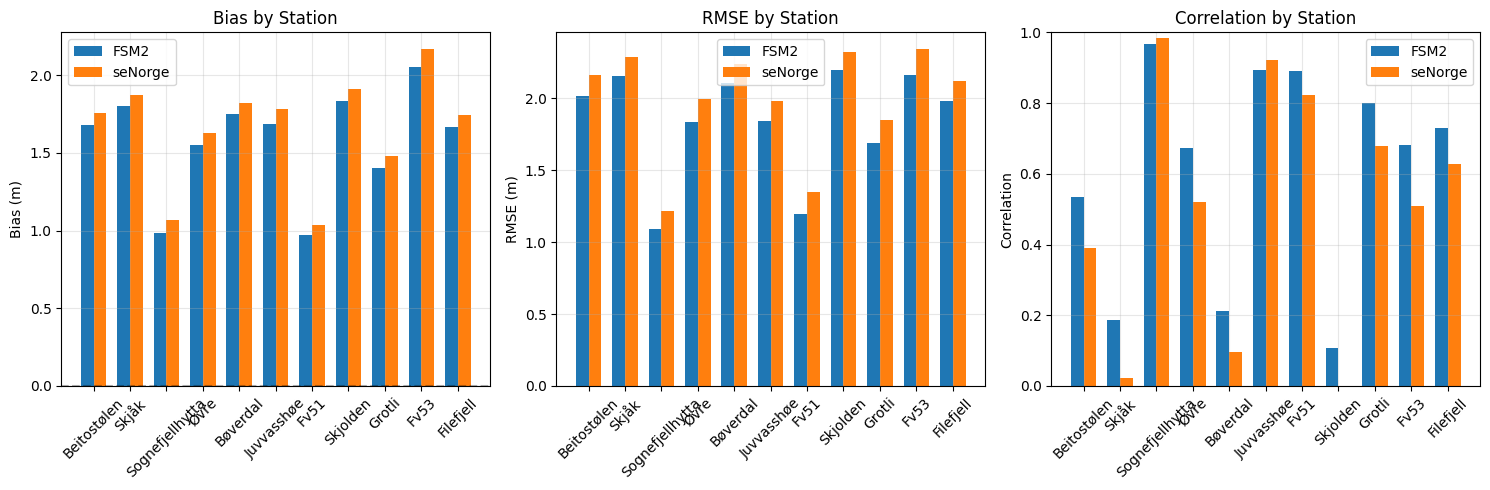

Figure saved to: ../data/processed/multi_station_comparison.png


In [23]:
# Create comparison plots
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Bias comparison
x_pos = np.arange(len(results_df))
width = 0.35

axes[0].bar(x_pos - width/2, results_df['FSM2_Bias'], width, label='FSM2')
axes[0].bar(x_pos + width/2, results_df['seNorge_Bias'], width, label='seNorge')
axes[0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
axes[0].set_ylabel('Bias (m)')
axes[0].set_title('Bias by Station')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels([s.split()[0] for s in results_df['Station']], rotation=45)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# RMSE comparison
axes[1].bar(x_pos - width/2, results_df['FSM2_RMSE'], width, label='FSM2')
axes[1].bar(x_pos + width/2, results_df['seNorge_RMSE'], width, label='seNorge')
axes[1].set_ylabel('RMSE (m)')
axes[1].set_title('RMSE by Station')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels([s.split()[0] for s in results_df['Station']], rotation=45)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Correlation comparison
axes[2].bar(x_pos - width/2, results_df['FSM2_Corr'], width, label='FSM2')
axes[2].bar(x_pos + width/2, results_df['seNorge_Corr'], width, label='seNorge')
axes[2].set_ylabel('Correlation')
axes[2].set_title('Correlation by Station')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels([s.split()[0] for s in results_df['Station']], rotation=45)
axes[2].set_ylim([0, 1])
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../data/processed/multi_station_comparison.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to: ../data/processed/multi_station_comparison.png")

## 9. 4-Panel Visualization: All Three Models

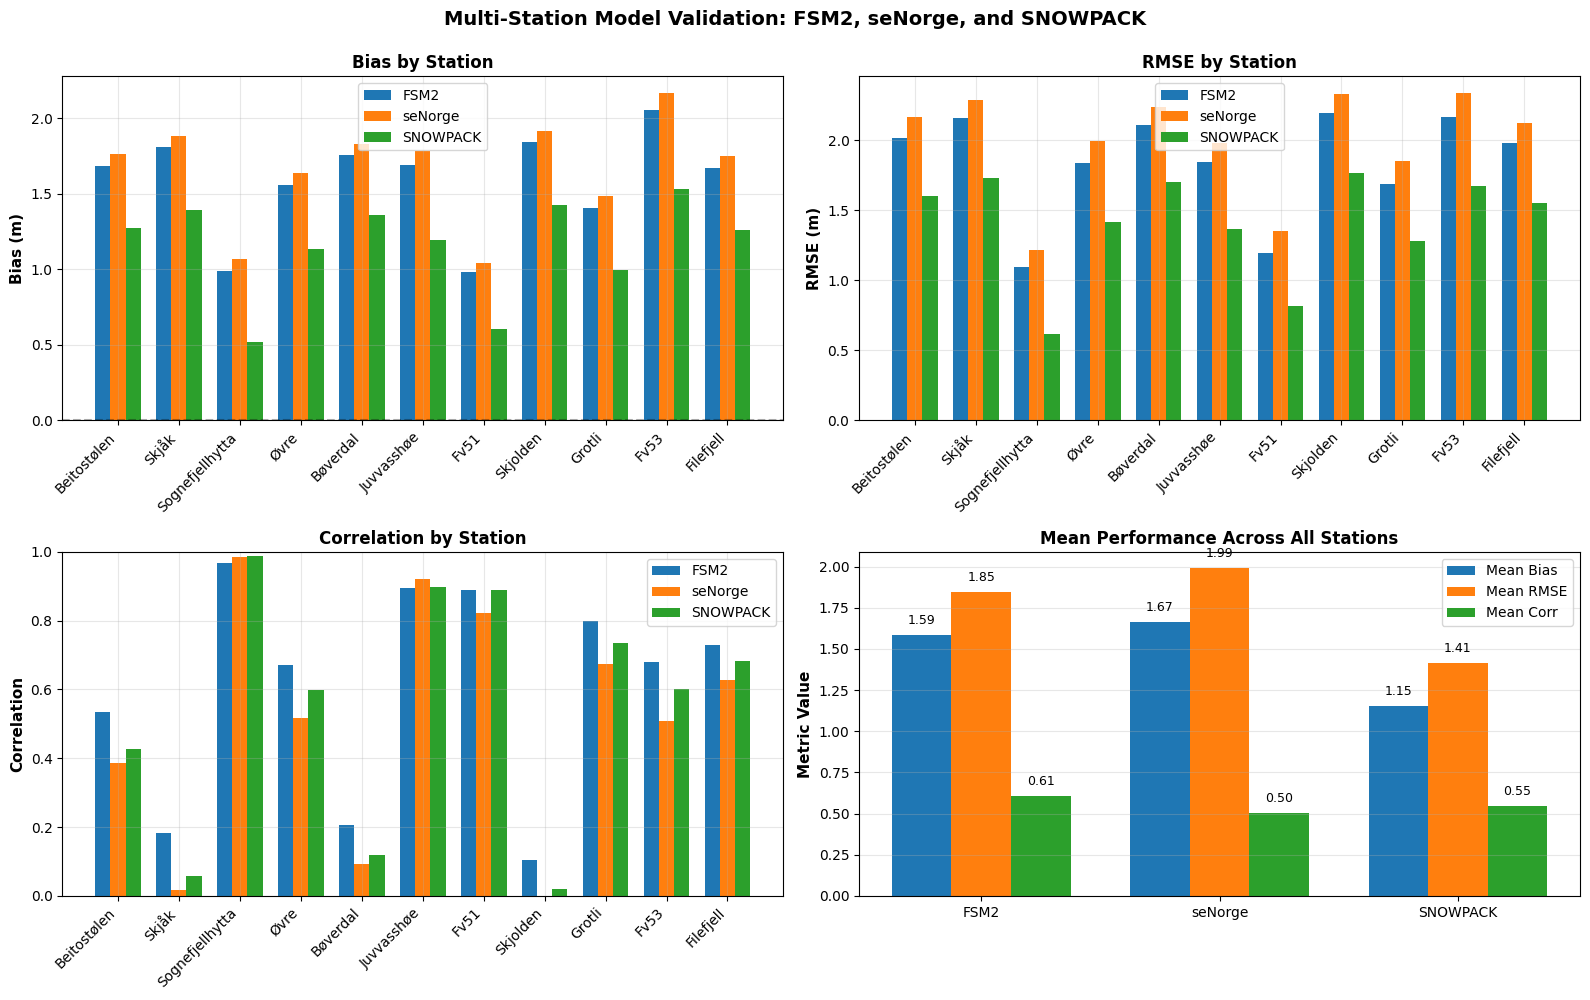

Figure saved to: ../data/processed/multi_station_comparison_3models.png


In [29]:
# Create 4-panel comparison plot with all three models
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

x_pos = np.arange(len(results_df))
width = 0.25

# Panel 1: Bias comparison
ax = axes[0, 0]
ax.bar(x_pos - width, results_df['FSM2_Bias'], width, label='FSM2')
ax.bar(x_pos, results_df['seNorge_Bias'], width, label='seNorge')
ax.bar(x_pos + width, results_df['SNOWPACK_Bias'], width, label='SNOWPACK')
ax.axhline(y=0, color='k', linestyle='--', alpha=0.3)
ax.set_ylabel('Bias (m)', fontsize=11, fontweight='bold')
ax.set_title('Bias by Station', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([s.split()[0] for s in results_df['Station']], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel 2: RMSE comparison
ax = axes[0, 1]
ax.bar(x_pos - width, results_df['FSM2_RMSE'], width, label='FSM2')
ax.bar(x_pos, results_df['seNorge_RMSE'], width, label='seNorge')
ax.bar(x_pos + width, results_df['SNOWPACK_RMSE'], width, label='SNOWPACK')
ax.set_ylabel('RMSE (m)', fontsize=11, fontweight='bold')
ax.set_title('RMSE by Station', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([s.split()[0] for s in results_df['Station']], rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel 3: Correlation comparison
ax = axes[1, 0]
ax.bar(x_pos - width, results_df['FSM2_Corr'], width, label='FSM2')
ax.bar(x_pos, results_df['seNorge_Corr'], width, label='seNorge')
ax.bar(x_pos + width, results_df['SNOWPACK_Corr'], width, label='SNOWPACK')
ax.set_ylabel('Correlation', fontsize=11, fontweight='bold')
ax.set_title('Correlation by Station', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels([s.split()[0] for s in results_df['Station']], rotation=45, ha='right')
ax.set_ylim([0, 1])
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Panel 4: Mean performance summary
ax = axes[1, 1]
models = ['FSM2', 'seNorge', 'SNOWPACK']
mean_bias = [results_df['FSM2_Bias'].mean(), results_df['seNorge_Bias'].mean(), results_df['SNOWPACK_Bias'].mean()]
mean_rmse = [results_df['FSM2_RMSE'].mean(), results_df['seNorge_RMSE'].mean(), results_df['SNOWPACK_RMSE'].mean()]
mean_corr = [results_df['FSM2_Corr'].mean(), results_df['seNorge_Corr'].mean(), results_df['SNOWPACK_Corr'].mean()]

x_models = np.arange(len(models))
width_models = 0.25

ax.bar(x_models - width_models, mean_bias, width_models, label='Mean Bias')
ax.bar(x_models, mean_rmse, width_models, label='Mean RMSE')
ax.bar(x_models + width_models, mean_corr, width_models, label='Mean Corr')
ax.set_ylabel('Metric Value', fontsize=11, fontweight='bold')
ax.set_title('Mean Performance Across All Stations', fontsize=12, fontweight='bold')
ax.set_xticks(x_models)
ax.set_xticklabels(models)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (b, r, c) in enumerate(zip(mean_bias, mean_rmse, mean_corr)):
    ax.text(i - width_models, b + 0.05, f'{b:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(i, r + 0.05, f'{r:.2f}', ha='center', va='bottom', fontsize=9)
    ax.text(i + width_models, c + 0.05, f'{c:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Multi-Station Model Validation: FSM2, seNorge, and SNOWPACK', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig("../data/processed/multi_station_comparison_3models.png", dpi=300, bbox_inches='tight')
plt.show()
print("Figure saved to: ../data/processed/multi_station_comparison_3models.png")